In [1]:
import pandas as pd
import numpy as np

In [4]:
df =pd.read_csv(r"Clustering_Data.csv")
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740,3
174,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750,3
175,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835,3
176,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840,3


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Customer_Segment      178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [6]:
df.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
Customer_Segment        0
dtype: int64

In [7]:
df.dtypes

Alcohol                 float64
Malic_Acid              float64
Ash                     float64
Ash_Alcanity            float64
Magnesium                 int64
Total_Phenols           float64
Flavanoids              float64
Nonflavanoid_Phenols    float64
Proanthocyanins         float64
Color_Intensity         float64
Hue                     float64
OD280                   float64
Proline                   int64
Customer_Segment          int64
dtype: object

In [10]:
X = df.iloc[:, :-1].astype(float)

X = (X - X.min()) / (X.max() - X.min())   #scaling (min-max)

df[df.columns[:-1]] = X
df

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Customer_Segment
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341,1
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642,1
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933,1
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347,1
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.705263,0.970356,0.582888,0.510309,0.271739,0.241379,0.056962,0.735849,0.205047,0.547782,0.130081,0.172161,0.329529,3
174,0.623684,0.626482,0.598930,0.639175,0.347826,0.282759,0.086498,0.566038,0.315457,0.513652,0.178862,0.106227,0.336662,3
175,0.589474,0.699605,0.481283,0.484536,0.543478,0.210345,0.073840,0.566038,0.296530,0.761092,0.089431,0.106227,0.397290,3
176,0.563158,0.365613,0.540107,0.484536,0.543478,0.231034,0.071730,0.754717,0.331230,0.684300,0.097561,0.128205,0.400856,3


In [14]:
X = df.iloc[:, :-1].values   #this converts dataframe into array
y = df.iloc[:, -1].values

In [15]:
#this splits the data we have been given

split = int(0.8 * len(df))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [16]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))  

In [17]:
def knn_predict(X_train, y_train, test_point, k):      #we five the test point here from where we want distance and k value

    distances = []

    for i in range(len(X_train)):
        dist = euclidean_distance(test_point, X_train[i])
        distances.append((dist, y_train[i]))

    distances.sort(key=lambda x: x[0])

    neighbors = distances[:k]

    labels = [label for _, label in neighbors]

    prediction = max(set(labels), key=labels.count)

    return prediction

In [20]:
k = 5
predictions = []

for t in X_test:
    pred = knn_predict(X_train, y_train, t, k)
    predictions.append(pred)

In [21]:
correct = 0

for i in range(len(y_test)):
    if predictions[i] == y_test[i]:
        correct += 1

accuracy = correct / len(y_test)

print("Accuracy:", accuracy)

Accuracy: 0.9722222222222222


In [25]:
import matplotlib.pyplot as plt

acc=[]

errors= []

r=range(1,16)

for k in r:

    pred=[]

    for x in X_test:
        p = knn_predict(X_train, y_train, x, k)
        pred.append(p)

    right = 0

    for i in range (len(y_test)):
        if pred[i]== y_test[i]:
            right += 1
    ac = right / len(y_test)

    acc.append(ac)
    
    err = 1- ac

    errors.append(err)


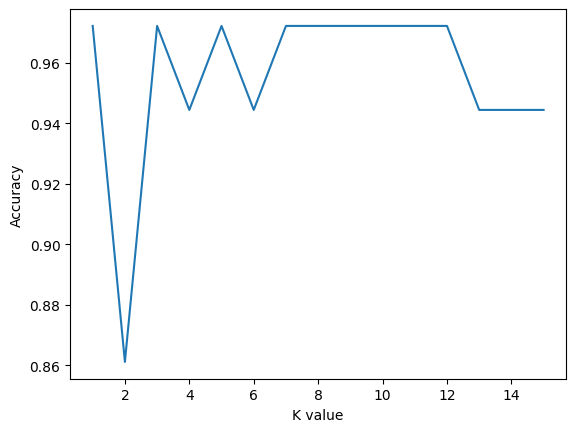

In [24]:
plt.plot(r, acc)

plt.xlabel("K value")
plt.ylabel("Accuracy")

plt.show()

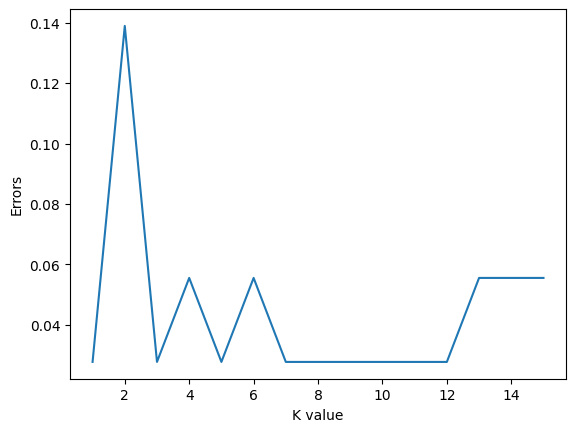

In [26]:
plt.plot(r, errors)

plt.xlabel("K value")
plt.ylabel("Errors")

plt.show()